In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Installs
# ═══════════════════════════════════════════════════
!pip install -q semantic-kernel google-genai datasets scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.0/924.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:


# ═══════════════════════════════════════════════════
# CELL 2 — Imports + API setup
# ═══════════════════════════════════════════════════
import re, time, csv, getpass
import numpy as np
from collections import defaultdict
from google import genai
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from semantic_kernel import Kernel
from semantic_kernel.functions import kernel_function, KernelArguments

API_KEY = getpass.getpass("Enter Gemini API key: ")
client  = genai.Client(api_key=API_KEY)

Enter Gemini API key: ··········


In [ ]:

# ═══════════════════════════════════════════════════
# CELL 3 — Gemini call with retry backoff
# ═══════════════════════════════════════════════════
def ask_gemini(prompt: str, retries: int = 3, wait: float = 5.0) -> str:
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash", contents=prompt
            )
            return response.text.strip()
        except Exception as e:
            print(f"  [API error attempt {attempt+1}/{retries}]: {e}")
            if attempt < retries - 1:
                time.sleep(wait * (attempt + 1))
    return ""

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 3.5 — Solution RAG: TF-IDF over GSM8K train
# ═══════════════════════════════════════════════════
print("Building solution RAG index from GSM8K train split...")
train_ds        = load_dataset("gsm8k", "main", split="train")
train_questions = [s["question"] for s in train_ds]
train_answers   = [s["answer"]   for s in train_ds]

vectorizer   = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(train_questions)
print(f"Solution RAG ready: {len(train_questions)} examples indexed.")

def retrieve_examples(query: str, top_k: int = 3) -> str:
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    return "\n\n---\n\n".join(
        f"Example Problem:\n{train_questions[i]}\nExample Solution:\n{train_answers[i]}"
        for i in top_idx
    )

Building solution RAG index from GSM8K train split...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Solution RAG ready: 7473 examples indexed.


In [ ]:



# ═══════════════════════════════════════════════════
# CELL 3.6 — Failure Pattern RAG (self-growing memory)
# ═══════════════════════════════════════════════════
failure_memory = []   # grows during evaluation run

FAILURE_TYPES = ["ARITHMETIC_ERROR", "MISREAD_PROBLEM",
                 "MISSING_CONSTRAINT", "LOGIC_GAP"]

def add_failure(question: str, wrong_answer: str,
                failure_type: str, reason: str, correct_answer: str = None):
    failure_memory.append({
        "question":       question,
        "wrong_answer":   wrong_answer,
        "failure_type":   failure_type,
        "reason":         reason,
        "correct_answer": correct_answer
    })

def retrieve_similar_failures(query: str, top_k: int = 2) -> str:
    """
    Uses the same TF-IDF vectorizer (fit on train) to embed stored failures
    and retrieve the most similar ones to the current query.
    Returns "" when memory is empty.
    """
    if not failure_memory:
        return ""
    fm_qs   = [f["question"] for f in failure_memory]
    fm_mat  = vectorizer.transform(fm_qs)
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, fm_mat).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    blocks  = []
    for idx in top_idx:
        f = failure_memory[idx]
        blk = (f"Past Failure [{f['failure_type']}]:\n"
               f"Problem   : {f['question']}\n"
               f"Wrong Ans : {f['wrong_answer']}\n"
               f"Why Wrong : {f['reason']}\n")
        if f["correct_answer"]:
            blk += f"Correct   : {f['correct_answer']}"
        blocks.append(blk)
    return "\n\n---\n\n".join(blocks)

In [ ]:


# ═══════════════════════════════════════════════════
# CELL 4 — Targeted recovery prompts per failure type
# ═══════════════════════════════════════════════════
RECOVERY_PROMPTS = {
    "ARITHMETIC_ERROR": """You are a math recovery agent. The model made a CALCULATION MISTAKE.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Redo every arithmetic operation from scratch, showing each step explicitly.
Double-check each multiplication, division, addition, and subtraction.
State ONLY the corrected final numeric answer on the last line.""",

    "MISREAD_PROBLEM": """You are a math recovery agent. The model MISUNDERSTOOD THE QUESTION.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Re-read the problem carefully. Identify exactly what quantity is being asked for.
Then solve step by step for that specific quantity.
State ONLY the final numeric answer on the last line.""",

    "MISSING_CONSTRAINT": """You are a math recovery agent. The model IGNORED A CONSTRAINT.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
List every constraint and condition stated in the problem before solving.
Ensure your solution satisfies ALL of them.
State ONLY the final numeric answer on the last line.""",

    "LOGIC_GAP": """You are a math recovery agent. The model had a FLAWED REASONING CHAIN.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Rebuild the reasoning chain from premises to conclusion.
Justify every logical step explicitly before moving to the next.
State ONLY the final numeric answer on the last line.""",
}

In [ ]:


# ═══════════════════════════════════════════════════
# CELL 5 — Agent definitions + kernel registration
# ═══════════════════════════════════════════════════
kernel = Kernel()

@kernel_function(name="execution_agent",
                 description="Solves a math task with solution RAG + optional feedback")
def execution_agent(task: str, feedback: str = "") -> str:
    rag_ctx = retrieve_examples(task, top_k=3)
    prompt  = f"""You are a math solver. Use the worked examples below as a guide,
then solve the new problem step by step.
State ONLY the final numeric answer on the last line.
Do not include units, currency symbols, or commas.

=== Relevant Worked Examples ===
{rag_ctx}

=== New Problem ===
{task}
{"=== Feedback from previous attempt ===\n" + feedback if feedback else ""}
"""
    return ask_gemini(prompt)


@kernel_function(name="verification_agent",
                 description="Verifies a math answer by independently re-solving")
def verification_agent(task: str, output: str) -> str:
    prompt = f"""You are a strict math verification agent. Your job is to catch errors.

Problem:
{task}

Claimed Answer:
{output}

Instructions:
1. Solve the problem yourself from scratch, step by step. Do NOT look at the claimed answer yet.
2. Extract your own final numeric answer.
3. Compare your answer to the claimed answer.
4. If they match exactly (ignoring $, commas, units), respond VALID.
5. If they differ in any way, respond INVALID.

Be strict. Do not give benefit of the doubt. If you get a different number, it is INVALID.

Respond ONLY with:
VALID
or
INVALID
Reason: <one sentence: what you got vs what was claimed>
"""
    return ask_gemini(prompt)


@kernel_function(name="classifier_agent",
                 description="Classifies the failure type of a wrong math answer")
def classifier_agent(task: str, output: str, reason: str) -> str:
    prompt = f"""Classify this math reasoning failure into exactly one category.

Problem     : {task}
Wrong Output: {output}
Failure Note: {reason}

Categories (pick ONLY one):
- ARITHMETIC_ERROR    : Correct approach but wrong calculation
- MISREAD_PROBLEM     : Misunderstood what the problem is asking
- MISSING_CONSTRAINT  : Ignored a condition or constraint in the problem
- LOGIC_GAP           : Correct numbers but flawed reasoning chain

Respond with ONLY the category name, nothing else.
"""
    raw = ask_gemini(prompt).strip().upper()
    return raw if raw in FAILURE_TYPES else "ARITHMETIC_ERROR"  # safe default


@kernel_function(name="recovery_agent",
                 description="Targeted recovery using failure type and past failure memory")
def recovery_agent(task: str, output: str,
                   reason: str, failure_type: str) -> str:
    template    = RECOVERY_PROMPTS.get(failure_type, RECOVERY_PROMPTS["ARITHMETIC_ERROR"])
    past_fails  = retrieve_similar_failures(task, top_k=2)
    past_block  = (f"\n=== Similar Past Failures (learn from these) ===\n{past_fails}\n"
                   if past_fails else "")
    base_prompt = template.format(task=task, output=output, reason=reason)
    return ask_gemini(base_prompt + past_block)


kernel.add_function(plugin_name="agents", function=execution_agent)
kernel.add_function(plugin_name="agents", function=verification_agent)
kernel.add_function(plugin_name="agents", function=classifier_agent)
kernel.add_function(plugin_name="agents", function=recovery_agent)
print("Kernel functions registered:", list(kernel.get_plugin("agents").functions))

Kernel functions registered: ['execution_agent', 'verification_agent', 'classifier_agent', 'recovery_agent']


In [ ]:


# ═══════════════════════════════════════════════════
# CELL 6 — Normalization + ground truth extraction
# ═══════════════════════════════════════════════════
def normalize_answer(text: str) -> str:
    text = re.sub(r'[$,€£%]', '', text)
    nums = re.findall(r'-?\d+\.?\d*', text)
    return nums[-1] if nums else text.strip()

def extract_ground_truth(answer_text: str) -> str:
    if "####" in answer_text:
        return normalize_answer(answer_text.split("####")[-1].strip())
    return None

In [ ]:
# Replace run_pipeline signature to accept ground_truth (already does)
# and pass it into a hybrid verification step.

# ── Drop-in replacement for the kernel verification_agent ──────────────
# Keep the existing @kernel_function verification_agent as-is for logging.
# Add this wrapper that's called inside run_pipeline instead:

def hybrid_verify(task: str, output: str, ground_truth: str = None) -> tuple[bool, str]:
    """
    Returns (flagged_invalid: bool, reason: str).
    Step 1: deterministic exact-match against GT (if available).
    Step 2: if no GT or match unclear, fall back to LLM verifier.
    """
    norm_out = normalize_answer(output)

    # Step 1 — deterministic (ground truth available during evaluation)
    if ground_truth is not None:
        if norm_out == ground_truth:
            return False, "Deterministic: exact match"
        else:
            return True, f"Deterministic: got {norm_out}, expected {ground_truth}"

    # Step 2 — LLM fallback (used for ARC/BoolQ or when GT unavailable)
    prompt = f"""You are a strict math verification agent.

Problem:
{task}

Claimed Answer:
{output}

Solve the problem yourself step by step. Then compare your answer to the claimed answer.
If they match, respond VALID. If they differ, respond INVALID.

Respond ONLY with:
VALID
or
INVALID
Reason: <one sentence>
"""
    verdict = ask_gemini(prompt)
    flagged = "INVALID" in verdict
    reason  = verdict.split("Reason:")[-1].strip() if "Reason:" in verdict else verdict
    return flagged, reason

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 7 — Pipeline with taxonomy + failure memory
# ═══════════════════════════════════════════════════
MAX_RETRIES      = 2
INTER_CALL_DELAY = 4

async def run_pipeline(task: str, ground_truth: str = None):
    feedback, output, first_attempt_ans = "", "", None
    verdicts_log, failure_types_seen    = [], []

    for attempt in range(MAX_RETRIES + 1):
        result = await kernel.invoke(
            plugin_name="agents", function_name="execution_agent",
            arguments=KernelArguments(task=task, feedback=feedback)
        )
        output = str(result)
        if attempt == 0:
            first_attempt_ans = normalize_answer(output)

        flagged, reason = hybrid_verify(task, output, ground_truth)
        verdict = f"{'INVALID' if flagged else 'VALID'}\nReason: {reason}"

        verdicts_log.append({
            "attempt": attempt + 1,
            "verdict_raw": verdict[:80],
            "flagged_invalid": flagged,
            "reason": reason
        })
        print(f"  Attempt {attempt+1} | verdict: {verdict[:60]}")

        if not flagged:
            return normalize_answer(output), attempt + 1, first_attempt_ans, verdicts_log, failure_types_seen

        # ── Classify failure ──────────────────────────────
        clf_result = await kernel.invoke(
            plugin_name="agents", function_name="classifier_agent",
            arguments=KernelArguments(task=task, output=output, reason=reason)
        )
        failure_type = str(clf_result).strip().upper()
        if failure_type not in FAILURE_TYPES:
            failure_type = "ARITHMETIC_ERROR"
        failure_types_seen.append(failure_type)
        print(f"  Classified: {failure_type}")

        # ── Add to failure memory ─────────────────────────
        add_failure(task, normalize_answer(output),
                    failure_type, reason, ground_truth)

        # ── Targeted recovery ─────────────────────────────
        recovery_result = await kernel.invoke(
            plugin_name="agents", function_name="recovery_agent",
            arguments=KernelArguments(
                task=task, output=output,
                reason=reason, failure_type=failure_type
            )
        )
        feedback = str(recovery_result)

    return normalize_answer(output), MAX_RETRIES + 1, first_attempt_ans, verdicts_log, failure_types_seen


async def run_baseline(task: str) -> str:
    result = await kernel.invoke(
        plugin_name="agents", function_name="execution_agent",
        arguments=KernelArguments(task=task, feedback="")
    )
    return normalize_answer(str(result))

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 7.5 — Metric helpers
# ═══════════════════════════════════════════════════
def compute_f1(tp, fp, fn):
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def print_metrics(n, baseline_correct, pipeline_correct,
                  verif_tp, verif_fp, verif_tn, verif_fn,
                  rsr_num, rsr_den, total_attempts,
                  failure_type_counts, failure_type_recovered):
    precision, recall, f1 = compute_f1(verif_tp, verif_fp, verif_fn)
    fdr = verif_tp / (verif_tp + verif_fn) if (verif_tp + verif_fn) > 0 else 0.0
    fpr = verif_fp / (verif_fp + verif_tn) if (verif_fp + verif_tn) > 0 else 0.0
    rsr = rsr_num  / rsr_den               if rsr_den > 0             else 0.0
    aat = total_attempts / n

    W = 60
    print(f"\n{'='*W}")
    print(f"{'EVALUATION RESULTS':^{W}}")
    print(f"{'='*W}")
    print(f"  Samples Evaluated              : {n}")

    print(f"\n  ── Task Success Rate (TSR) ──")
    print(f"  Baseline TSR                   : {baseline_correct/n:.2%}  ({baseline_correct}/{n})")
    print(f"  Pipeline TSR                   : {pipeline_correct/n:.2%}  ({pipeline_correct}/{n})")

    print(f"\n  ── Verification Agent ──")
    print(f"  TP / FP / TN / FN              : {verif_tp} / {verif_fp} / {verif_tn} / {verif_fn}")
    print(f"  Failure Detection Rate (FDR)   : {fdr:.2%}")
    print(f"  False Positive Rate (FPR)      : {fpr:.2%}")
    print(f"  Precision                      : {precision:.2%}")
    print(f"  Recall                         : {recall:.2%}")
    print(f"  F1 Score                       : {f1:.4f}")

    print(f"\n  ── Recovery & Efficiency ──")
    print(f"  Recovery Success Rate (RSR)    : {rsr:.2%}  ({rsr_num}/{rsr_den})")
    print(f"  Avg Attempts per Task (AAT)    : {aat:.2f}")
    print(f"  Failure Memory Size            : {len(failure_memory)}")

    print(f"\n  ── Failure Taxonomy Breakdown ──")
    for ft in FAILURE_TYPES:
        total   = failure_type_counts.get(ft, 0)
        recov   = failure_type_recovered.get(ft, 0)
        rsr_ft  = recov / total if total > 0 else 0.0
        print(f"  {ft:<22} : {total:>3} failures | RSR: {rsr_ft:.2%} ({recov}/{total})")

    print(f"{'='*W}\n")


In [ ]:


# ═══════════════════════════════════════════════════
# CELL 8 — Load test dataset
# ═══════════════════════════════════════════════════
dataset = load_dataset("gsm8k", "main", split="test")
print("Test set loaded. Total samples:", len(dataset))


Test set loaded. Total samples: 1319


In [ ]:


# ═══════════════════════════════════════════════════
# CELL 9 — Sanity check (3 samples)
# ═══════════════════════════════════════════════════
failure_memory.clear()
for i in range(3):
    s  = dataset[i]
    gt = extract_ground_truth(s["answer"])
    b  = await run_baseline(s["question"])
    p, attempts, fa, _, ftypes = await run_pipeline(s["question"], ground_truth=gt)
    print(f"[{i}] GT: {gt} | Baseline: {b} | First: {fa} | Pipeline: {p} "
          f"(attempts: {attempts}, types: {ftypes})")
    time.sleep(INTER_CALL_DELAY)

  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[0] GT: 18 | Baseline: 18 | First: 18 | Pipeline: 18 (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[1] GT: 3 | Baseline: 3 | First: 3 | Pipeline: 3 (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[2] GT: 70000 | Baseline: 70000 | First: 70000 | Pipeline: 70000 (attempts: 1, types: [])


In [ ]:



# ═══════════════════════════════════════════════════
# CELL 10 — Full evaluation
# ═══════════════════════════════════════════════════
async def evaluate(n_samples: int = 50, csv_path: str = "gsm8k_results.csv"):
    failure_memory.clear()   # reset memory at start of each run

    baseline_correct = pipeline_correct = 0
    verif_tp = verif_fp = verif_tn = verif_fn = 0
    rsr_num  = rsr_den  = total_attempts = 0

    # Taxonomy counters
    failure_type_counts    = defaultdict(int)   # how often each type appears
    failure_type_recovered = defaultdict(int)   # how often recovery succeeded per type

    # For plotting RSR over time
    rsr_over_time = []

    fieldnames = [
        "index", "question", "ground_truth",
        "baseline_output", "baseline_correct",
        "first_attempt_output", "first_attempt_correct",
        "verif_flagged_invalid", "verif_decision_correct",
        "failure_types",
        "pipeline_output", "pipeline_attempts", "pipeline_correct",
        "recovery_triggered", "recovery_succeeded",
        "failure_memory_size_at_solve"
    ]

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for i in range(n_samples):
            sample       = dataset[i]
            question     = sample["question"]
            ground_truth = extract_ground_truth(sample["answer"])
            mem_size_before = len(failure_memory)

            print(f"\n[{i+1}/{n_samples}] {question[:80]}...")
            print(f"  Ground truth: {ground_truth} | Memory size: {mem_size_before}")

            # ── Baseline ──────────────────────────
            b_out     = await run_baseline(question)
            b_correct = (b_out == ground_truth)
            if b_correct:
                baseline_correct += 1
            print(f"  Baseline: {b_out} → {'✓' if b_correct else '✗'}")
            time.sleep(INTER_CALL_DELAY)

            # ── Pipeline ──────────────────────────
            p_out, attempts, first_ans, verdicts_log, ftypes = \
                await run_pipeline(question, ground_truth=ground_truth)
            p_correct  = (p_out == ground_truth)
            fa_correct = (first_ans == ground_truth)
            if p_correct:
                pipeline_correct += 1
            total_attempts += attempts
            print(f"  Pipeline: {p_out} (attempts: {attempts}) → {'✓' if p_correct else '✗'}")

            # ── Verification F1 ───────────────────
            first_flagged = verdicts_log[0]["flagged_invalid"]
            if   first_flagged and not fa_correct:  verif_tp += 1
            elif first_flagged and fa_correct:      verif_fp += 1
            elif not first_flagged and fa_correct:  verif_tn += 1
            else:                                   verif_fn += 1

            # ── RSR + taxonomy ────────────────────
            recovery_triggered = not fa_correct and first_flagged
            recovery_succeeded = recovery_triggered and p_correct
            if not fa_correct:
                rsr_den += 1
                if p_correct:
                    rsr_num += 1
            for ft in ftypes:
                failure_type_counts[ft] += 1
                if p_correct:
                    failure_type_recovered[ft] += 1

            rsr_so_far = rsr_num / rsr_den if rsr_den > 0 else 0.0
            rsr_over_time.append({"sample": i + 1, "rsr": rsr_so_far,
                                  "memory_size": len(failure_memory)})

            writer.writerow({
                "index":                     i,
                "question":                  question,
                "ground_truth":              ground_truth,
                "baseline_output":           b_out,
                "baseline_correct":          b_correct,
                "first_attempt_output":      first_ans,
                "first_attempt_correct":     fa_correct,
                "verif_flagged_invalid":     first_flagged,
                "verif_decision_correct":    (
                    (first_flagged and not fa_correct) or
                    (not first_flagged and fa_correct)
                ),
                "failure_types":             "|".join(ftypes) if ftypes else "NONE",
                "pipeline_output":           p_out,
                "pipeline_attempts":         attempts,
                "pipeline_correct":          p_correct,
                "recovery_triggered":        recovery_triggered,
                "recovery_succeeded":        recovery_succeeded,
                "failure_memory_size_at_solve": mem_size_before
            })
            f.flush()
            time.sleep(INTER_CALL_DELAY)

    print_metrics(
        n_samples, baseline_correct, pipeline_correct,
        verif_tp, verif_fp, verif_tn, verif_fn,
        rsr_num, rsr_den, total_attempts,
        failure_type_counts, failure_type_recovered
    )

    # Save RSR-over-time for plotting
    with open("rsr_over_time.csv", "w", newline="") as rf:
        rw = csv.DictWriter(rf, fieldnames=["sample", "rsr", "memory_size"])
        rw.writeheader()
        rw.writerows(rsr_over_time)

    print(f"Results      → {csv_path}")
    print(f"RSR timeline → rsr_over_time.csv")

await evaluate(n_samples=50, csv_path="gsm8k_results.csv")



[1/50] Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning an...
  Ground truth: 18 | Memory size: 0
  Baseline: 18 → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: 18 (attempts: 1) → ✓

[2/50] A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bol...
  Ground truth: 3 | Memory size: 0
  Baseline: 3 → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: 3 (attempts: 1) → ✓

[3/50] Josh decides to try flipping a house.  He buys a house for $80,000 and then puts...
  Ground truth: 70000 | Memory size: 0
  Baseline: 70000 → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: 70000 (attempts: 1) → ✓

[4/50] James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  ...
  Ground truth: 540 | Memory size: 0
  Baseline: 540 → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: 540 (attempts: 1) → ✓

[5/50] Every d

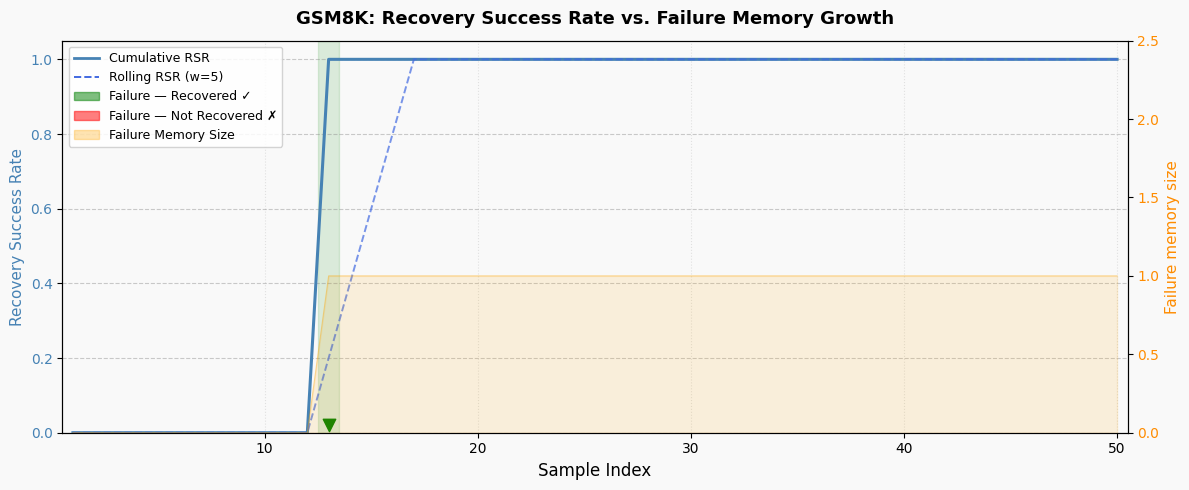

Plot saved to rsr_over_time.png


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 11 — Improved RSR Plot (GSM8K)
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import csv

# ── Load data ───────────────────────────────────────
rsr_data = list(csv.DictReader(open("/rsr_over_time.csv")))
res_data = list(csv.DictReader(open("/gsm8k_results.csv")))

xs  = [int(r["sample"])      for r in rsr_data]
rsr = [float(r["rsr"])       for r in rsr_data]
mem = [int(r["memory_size"]) for r in rsr_data]

# ── Rolling RSR (window=5) ──────────────────────────
window = 5
rolling_rsr = []
for i in range(len(rsr)):
    start = max(0, i - window + 1)
    subset = rsr[start:i+1]
    rolling_rsr.append(sum(subset) / len(subset))

# ── Identify failure points ─────────────────────────
fail_xs        = []
recovery_color = []
for i, r in enumerate(res_data):
    if r["verif_flagged_invalid"] == "True":
        fail_xs.append(i + 1)
        recovery_color.append(
            "green" if r["recovery_succeeded"] == "True" else "red"
        )

# ── Plot ────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#f9f9f9")
ax1.set_facecolor("#f9f9f9")

ax1.grid(axis="y", linestyle="--", alpha=0.4, color="gray")
ax1.grid(axis="x", linestyle=":",  alpha=0.2, color="gray")

# Memory size fill (right axis)
ax2 = ax1.twinx()
ax2.fill_between(xs, mem, alpha=0.12, color="orange")
ax2.plot(xs, mem, color="orange", linewidth=0.8, alpha=0.4)
ax2.set_ylabel("Failure memory size", color="darkorange", fontsize=11)
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, max(mem) * 2.5 if max(mem) > 0 else 5)

# Cumulative RSR line
ax1.plot(xs, rsr, color="steelblue", linewidth=2.2,
         label="Cumulative RSR", zorder=3)

# Rolling RSR line
ax1.plot(xs, rolling_rsr, color="royalblue", linewidth=1.4,
         linestyle="--", alpha=0.7,
         label=f"Rolling RSR (w={window})", zorder=3)

# Failure markers + recovery zones
for fx, fc in zip(fail_xs, recovery_color):
    ax1.axvspan(fx - 0.5, fx + 0.5, alpha=0.12, color=fc, zorder=1)
    ax1.scatter(fx, 0.02, color=fc, s=80, zorder=5,
                marker="v", clip_on=False)

ax1.set_xlabel("Sample Index", fontsize=12)
ax1.set_ylabel("Recovery Success Rate", color="steelblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(0, 1.05)
ax1.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
ax1.set_title("GSM8K: Recovery Success Rate vs. Failure Memory Growth",
              fontsize=13, fontweight="bold", pad=12)

# Legend
recovered_patch = mpatches.Patch(color="green",     alpha=0.5, label="Failure — Recovered ✓")
failed_patch    = mpatches.Patch(color="red",        alpha=0.5, label="Failure — Not Recovered ✗")
memory_patch    = mpatches.Patch(color="orange",     alpha=0.3, label="Failure Memory Size")
cum_line        = plt.Line2D([0],[0], color="steelblue", linewidth=2,   label="Cumulative RSR")
roll_line       = plt.Line2D([0],[0], color="royalblue", linewidth=1.4,
                              linestyle="--", label=f"Rolling RSR (w={window})")
ax1.legend(handles=[cum_line, roll_line, recovered_patch, failed_patch, memory_patch],
           loc="upper left", fontsize=9, framealpha=0.85)

fig.tight_layout()
plt.savefig("rsr_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to rsr_over_time.png")

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 12 — Interactive prompt tester
# ═══════════════════════════════════════════════════
# Paste any question here and run the full pipeline on it.
# Works for GSM8K (math), ARC (science MC), or BoolQ (yes/no).

MY_QUESTION = """
Janet has 3 brothers. Each brother has 2 sisters.
How many sisters does Janet have?
"""

# For ARC-style, format like:
# MY_QUESTION = """
# What is the chemical symbol for water?
# Choices:
# A. H2O
# B. CO2
# C. NaCl
# D. O2
# Answer with ONLY the letter (A, B, C, or D).
# """

# For BoolQ-style, format like:
# MY_QUESTION = """
# Passage: Water boils at 100 degrees Celsius at sea level.
# Question: Does water boil at 100 degrees Celsius?
# Answer with ONLY 'yes' or 'no'.
# """

print("=" * 60)
print("QUESTION:")
print(MY_QUESTION.strip())
print("=" * 60)

# ── Baseline A ──────────────────────────────────────
b_out = await run_baseline(MY_QUESTION.strip())
print(f"\nBaseline A (execution only): {b_out}")

# ── Baseline B (only available in ARC and BoolQ notebooks) ──
# bb_out, bb_flagged = await run_baseline_b(MY_QUESTION.strip(), ground_truth=None)
# print(f"Baseline B (exec + verif)  : {bb_out} | flagged: {bb_flagged}")

# ── Full Pipeline ───────────────────────────────────
print("\n--- Full Pipeline ---")
p_out, attempts, first_ans, verdicts_log, ftypes = \
    await run_pipeline(MY_QUESTION.strip(), ground_truth=None)

print(f"\nFirst attempt answer : {first_ans}")
print(f"Final answer         : {p_out}")
print(f"Attempts used        : {attempts}")
print(f"Failure types seen   : {ftypes if ftypes else 'None — passed on first attempt'}")

print("\n--- Verdict log ---")
for v in verdicts_log:
    print(f"  Attempt {v['attempt']} | {'INVALID' if v['flagged_invalid'] else 'VALID'} | {v['reason']}")

print("=" * 60)

QUESTION:
Janet has 3 brothers. Each brother has 2 sisters.
How many sisters does Janet have?

Baseline A (execution only): 1

--- Full Pipeline ---
  Attempt 1 | verdict: VALID
Reason: VALID

First attempt answer : 1
Final answer         : 1
Attempts used        : 1
Failure types seen   : None — passed on first attempt

--- Verdict log ---
  Attempt 1 | VALID | VALID
